<h2 style="color:blue" align="center">Tensorboard demo using handwritten digits classification using neural network</h2>

In this notebook we will classify handwritten digits using a simple neural network which has only input and output layers. We will than add a hidden layer and see how the performance of the model improves

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step 


In [3]:
len(X_train)

60000

In [4]:
len(X_test)

10000

In [5]:
X_train[0].shape

(28, 28)

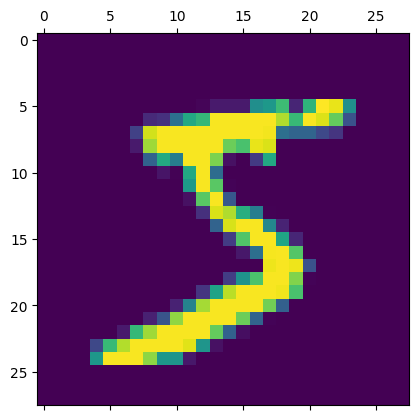

In [6]:
plt.matshow(X_train[0])

In [7]:
y_train[0]

5

In [8]:
X_train = X_train / 255
X_test = X_test / 255

In [9]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [10]:
X_train_flattened.shape

(60000, 784)

<h3 style='color:purple'>Using Flatten layer so that we don't have to call .reshape on input dataset</h3>

In [11]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)

model.fit(X_train, y_train, epochs=5, callbacks=[tb_callback])

C:\Users\Pavan-kumar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8697 - loss: 0.4629
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9615 - loss: 0.1359
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9734 - loss: 0.0903
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9793 - loss: 0.0671
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9841 - loss: 0.0503


In [12]:
# %load_ext tensorboard
# %tensorboard --logdir logs/fit

Either run above inline magic or go to git bash or your command prompt and type below to run it,
`tensorboard --logdir logs/`
This will launch tensorboard at this url which you can open in your browser `http://localhost:6006/`

In [13]:
model.get_weights()

[array([[ 0.0253842 , -0.00220026,  0.04201838, ..., -0.03089655,
         -0.07816162,  0.01882993],
        [ 0.07014529, -0.04826045,  0.04534854, ..., -0.0727548 ,
         -0.0679525 ,  0.07287297],
        [-0.01162279,  0.06901088, -0.07447541, ..., -0.03853149,
          0.08173007, -0.00066554],
        ...,
        [-0.03110138, -0.05638361,  0.07477532, ..., -0.04872607,
          0.06525017,  0.03907265],
        [ 0.06839627, -0.058302  , -0.0087328 , ...,  0.05205771,
          0.03683743,  0.01394659],
        [ 0.0409677 , -0.00465559,  0.0711672 , ..., -0.06995139,
         -0.0158589 , -0.00114054]], dtype=float32),
 array([-0.03173173, -0.03715418, -0.06005775, -0.0113329 ,  0.01141017,
        -0.07860006, -0.00613321,  0.05814152,  0.02680744,  0.01598272,
         0.12000711, -0.01847289, -0.00828742,  0.15969215,  0.16606344,
         0.11784609,  0.00475354,  0.12485355,  0.20970856,  0.05920897,
         0.03761443,  0.02654166, -0.06220149,  0.03371942,  0.032